# Section 4.2 Static AoA CFD Maps

本 notebook 用于绘制 Section 4.2 的核心图：`C_X(alpha)`, `C_Z(alpha)`, `C_m(alpha)` 的静态攻角 CFD lookup maps。

设计原则：正文主图只表达三件事：全攻角覆盖、最终模型输入系数、尾窗监测波动。静态 AoA CFD 只用于准静态载荷闭合，不用于 added mass 或 damping 识别。

## 1. Imports and publication style

本 cell 只负责依赖导入和科研绘图风格设置。图中文字保持英文，字体优先使用 Times New Roman。

In [8]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

try:
    from scipy.interpolate import PchipInterpolator
except Exception:
    PchipInterpolator = None

# 兼容普通 Python 执行；在 Jupyter 中 display 通常已存在。
try:
    display
except NameError:
    def display(obj):
        print(obj)

# 优先使用 Times New Roman；若当前环境未安装，则回退到 serif，避免 notebook 报错。
available_fonts = {font.name for font in mpl.font_manager.fontManager.ttflist}
font_family = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"

mpl.rcParams.update({
    "font.family": font_family,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.dpi": 140,
    "axes.linewidth": 0.85,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
    "xtick.minor.size": 2.2,
    "ytick.minor.size": 2.2,
    "legend.frameon": False,
})

pd.options.display.float_format = "{:.5g}".format
print(f"Using font: {font_family}")

Using font: Times New Roman


## 2. Paths and figure constants

本 cell 只定义输入文件和绘图语义。后续如果最终表位置变化，只需要改这里。

In [9]:
def find_repo_root(start=None):
    """从当前工作目录向上查找项目根目录。"""
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "project_memory.md").exists() and (candidate / "sim_flip").exists():
            return candidate
    raise FileNotFoundError("Cannot locate AD_v2_stage1_analysis project root.")


ROOT = find_repo_root()
LOOKUP_CSV = ROOT / "sim_flip" / "data" / "coefficients_final_lookup.csv"
METADATA_JSON = ROOT / "sim_flip" / "results" / "static_aoa_review" / "coefficients_final_lookup_metadata.json"
SOURCE_DIR = ROOT / "static_aoa_data"

# 85--125 deg 是分离和再附着风险最高的审查区间；用于数值核对表，不再放入正文核心图。
REVIEW_BAND = (85, 125)
AVERAGE_WINDOW_LABEL = "last 500 iterations"

# 多色但克制，避免整张图被单一色系支配。
PANEL_SPECS = [
    {"col": "Cx", "std": "Cx_raw_std", "ylabel": r"$C_X$", "color": "#1F5A85"},
    {"col": "Cz", "std": "Cz_raw_std", "ylabel": r"$C_Z$", "color": "#9C2F25"},
    {"col": "Cm", "std": "Cm_raw_std", "ylabel": r"$C_m$", "color": "#2F7D52"},
]

print(f"Project root: {ROOT}")
print(f"Lookup table: {LOOKUP_CSV}")

Project root: c:\AD_v2_stage1_analysis
Lookup table: c:\AD_v2_stage1_analysis\sim_flip\data\coefficients_final_lookup.csv


## 3. Load and validate the final lookup table

本 cell 做最小必要校验：列名、攻角覆盖、步长、源文件存在性、残差文件存在性。

In [10]:
required_cols = [
    "alpha_deg", "Cx", "Cz", "Cm",
    "source_file", "residual_file",
    "Cx_raw_std", "Cz_raw_std", "Cm_raw_std",
]

df = pd.read_csv(LOOKUP_CSV).sort_values("alpha_deg").reset_index(drop=True)
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in lookup table: {missing_cols}")

alpha = df["alpha_deg"].to_numpy(dtype=float)
step = np.diff(alpha)
if len(df) != 37:
    warnings.warn(f"Expected 37 AoA samples, got {len(df)}.")
if not np.allclose(step, 5):
    warnings.warn(f"AoA step is not uniformly 5 deg: {np.unique(step)}")

if METADATA_JSON.exists():
    metadata = json.loads(METADATA_JSON.read_text(encoding="utf-8"))
else:
    metadata = {}

df["source_exists"] = df["source_file"].map(lambda name: (SOURCE_DIR / str(name)).exists())
df["residual_exists"] = df["residual_file"].map(lambda name: (SOURCE_DIR / str(name)).exists())

summary = pd.DataFrame([
    ["AoA range", f"{df['alpha_deg'].min():.0f}--{df['alpha_deg'].max():.0f} deg"],
    ["AoA step", f"{np.median(step):.0f} deg"],
    ["Number of CFD samples", len(df)],
    ["Coefficient columns", "C_X, C_Z, C_m"],
    ["Monitor fluctuation", AVERAGE_WINDOW_LABEL],
    ["Source monitor files available", f"{int(df['source_exists'].sum())}/{len(df)}"],
    ["Residual files available", f"{int(df['residual_exists'].sum())}/{len(df)}"],
    ["Model role", metadata.get("model_role", "quasi-static coefficient lookup")],
])
summary.columns = ["Item", "Value"]
display(summary)

missing_residuals = df.loc[~df["residual_exists"], ["alpha_deg", "residual_file"]]
if len(missing_residuals):
    print("Missing residual files:")
    display(missing_residuals)

,Item,Value
0,AoA range,0--180 deg
1,AoA step,5 deg
2,Number of CFD samples,37
3,Coefficient columns,"C_X, C_Z, C_m"
4,Monitor fluctuation,last 500 iterations
5,Source monitor files available,37/37
6,Residual files available,36/37
7,Model role,"quasi-static C_X(alpha), C_Z(alpha), C_m(alpha..."


Missing residual files:


,alpha_deg,residual_file
3,15,Residuals_15.csv


## 4. Figure helper functions

本 cell 只放绘图工具函数。平滑线仅用于视觉引导，真实 CFD 采样点用空心圆保留。

In [24]:
def interpolate_for_display(x, y, x_dense):
    """平滑显示用插值；若 scipy 不可用则退回线性插值。"""
    if PchipInterpolator is not None:
        return PchipInterpolator(x, y)(x_dense)
    return np.interp(x_dense, x, y)


def style_coefficient_axis(ax, ylabel):
    """统一设置三张系数子图的版式。"""
    ax.axhline(0, color="0.75", lw=0.8, ls="--", zorder=0)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(which="both", top=False, right=False, labelsize=10)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))


def plot_static_aoa_maps(data):
    """绘制 Section 4.2 的正文候选 Fig. 8。"""
    x = data["alpha_deg"].to_numpy(dtype=float)
    x_dense = np.linspace(x.min(), x.max(), 721)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(11.6, 3.55),
        dpi=300,
        sharex=False,
        constrained_layout=False,
    )
    fig.subplots_adjust(left=0.065, right=0.985, bottom=0.25, top=0.80, wspace=0.34)

    for ax, spec in zip(axes, PANEL_SPECS):
        y = data[spec["col"]].to_numpy(dtype=float)
        y_std = data[spec["std"]].to_numpy(dtype=float)
        color = spec["color"]

        y_dense = interpolate_for_display(x, y, x_dense)
        std_dense = np.clip(interpolate_for_display(x, y_std, x_dense), 0, None)

        ax.fill_between(
            x_dense,
            y_dense - std_dense,
            y_dense + std_dense,
            color=color,
            alpha=0.14,
            lw=0,
            zorder=1,
        )
        ax.plot(x_dense, y_dense, color=color, lw=2.2, zorder=3)
        ax.scatter(x, y, s=24, facecolor="white", edgecolor=color, lw=0.9, zorder=4)

        pad = 0.08 * (np.nanmax(y + y_std) - np.nanmin(y - y_std) + 1e-9)
        ax.set_ylim(np.nanmin(y - y_std) - pad, np.nanmax(y + y_std) + pad)
        style_coefficient_axis(ax, spec["ylabel"])
        ax.set_xlabel(r"$\alpha$ (°)", fontsize=12)
        ax.set_xlim(-3, 183)
        ax.xaxis.set_major_locator(MultipleLocator(45))
        ax.xaxis.set_minor_locator(MultipleLocator(15))

    legend_handles = [
        Line2D([0], [0], marker="o", color="0.20", lw=0, markerfacecolor="white", markersize=5,
               label="CFD results"),
        Patch(facecolor="0.20", alpha=0.14, label="std. over final 500 iterations"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.52, 0.965),
        ncol=2,
        fontsize=9.5,
        columnspacing=1.25,
        handlelength=1.8,
    )
    fig.text(
        0.5,
        0.055,
        "Shaded bands show the standard deviation of coefficient monitors over the final 500 iterations; they are not full CFD uncertainty intervals.",
        ha="center",
        va="top",
        fontsize=9.2,
        color="0.25",
    )
    return fig, axes


## 5. Main Figure 8 candidate

这是 Section 4.2 的正文核心图候选。图只在 notebook 中显示，不额外保存文件。

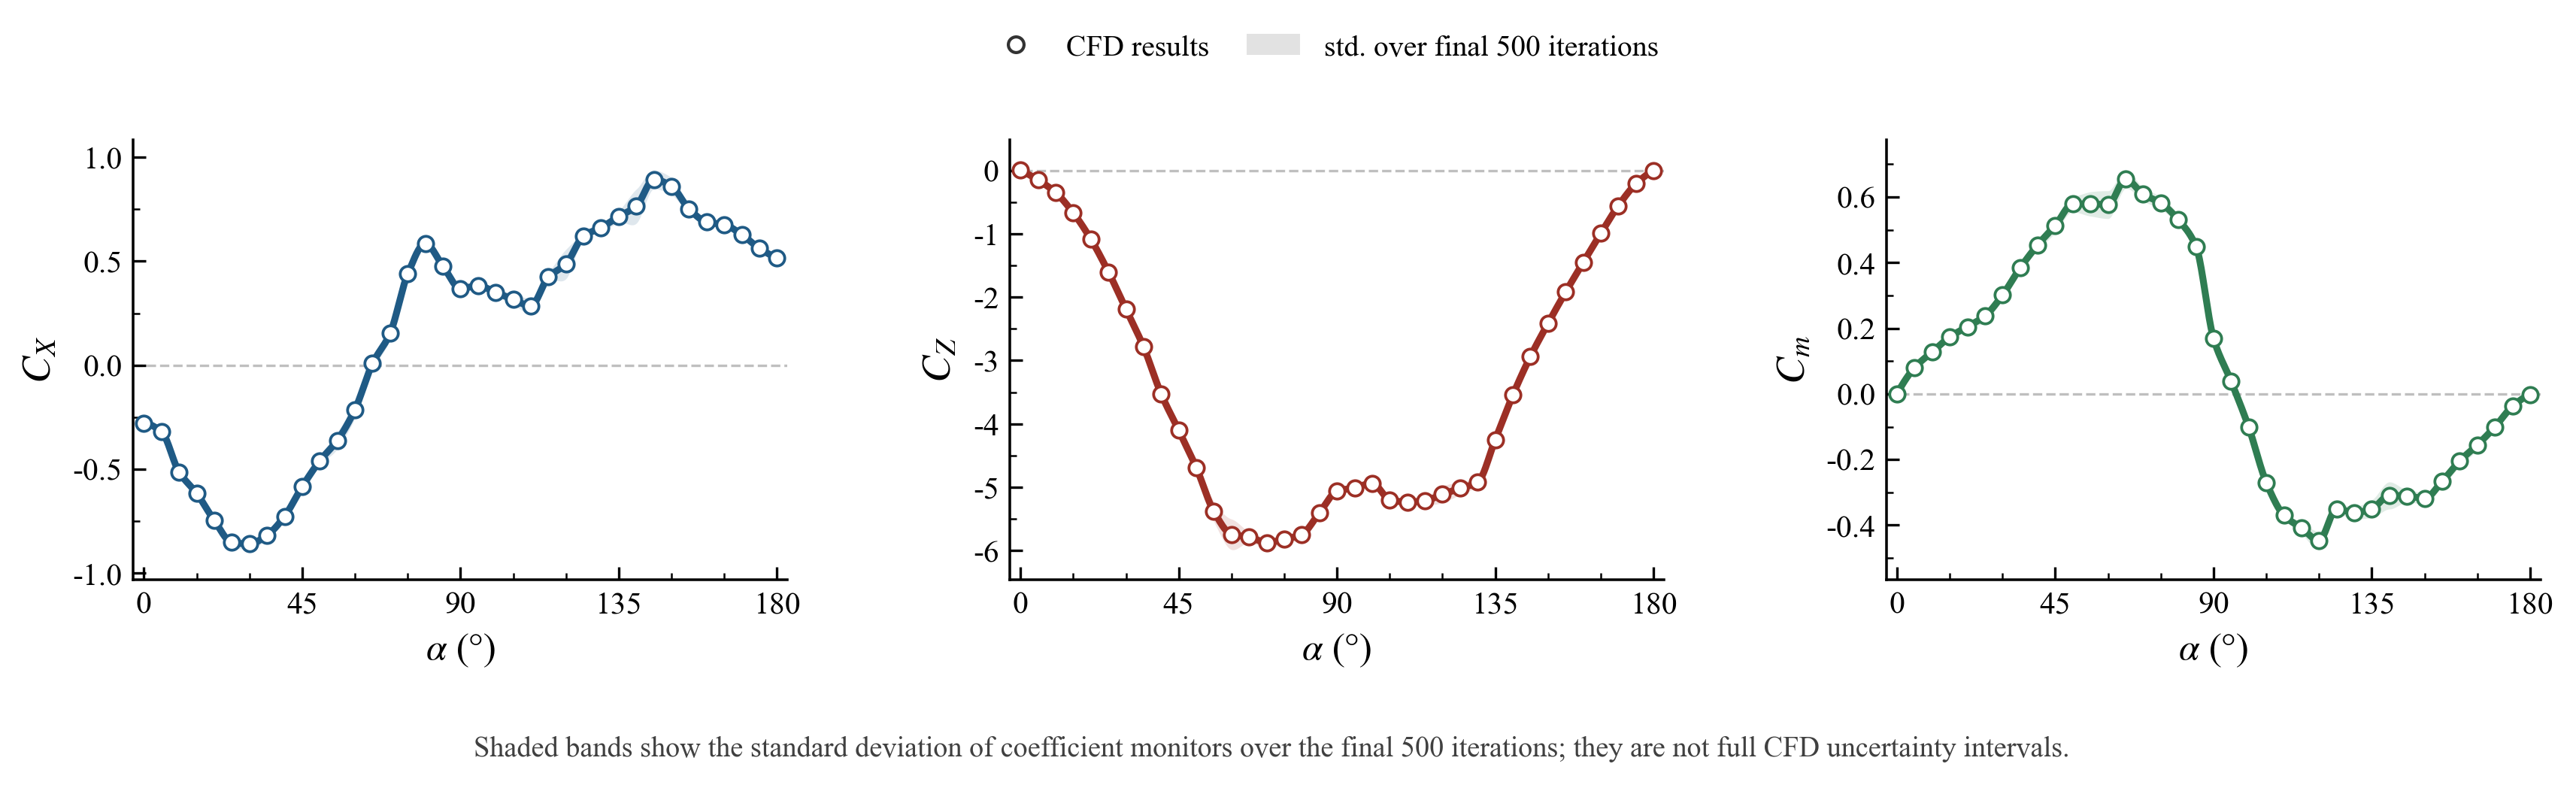

In [25]:
fig, axes = plot_static_aoa_maps(df)
plt.show()

## 6. Review-band values for manuscript checking

本 cell 给出 85--125 deg 审查区间内的最终系数和监测波动，方便核对文字表述。

In [13]:
review_band_table = df.loc[
    df["alpha_deg"].between(REVIEW_BAND[0], REVIEW_BAND[1]),
    ["alpha_deg", "Cx", "Cz", "Cm", "Cx_raw_std", "Cz_raw_std", "Cm_raw_std", "source_file", "residual_exists"],
].reset_index(drop=True)

display(review_band_table)

,alpha_deg,Cx,Cz,Cm,Cx_raw_std,Cz_raw_std,Cm_raw_std,source_file,residual_exists
0,85,0.4768,-5.4018,0.44984,0.025606,0.049791,0.014722,C_85_overmesh.csv,True
1,90,0.36834,-5.0617,0.1688,0.010339,0.020416,0.0098385,C_90_overmesh.csv,True
2,95,0.38225,-5.0081,0.038156,0.01255,0.031778,0.014726,C_95_overmesh.csv,True
3,100,0.34988,-4.9353,-0.10156,0.016166,0.020268,0.0087103,C_100_overmesh.csv,True
4,105,0.3163,-5.1953,-0.27033,0.027258,0.055723,0.014995,C_105_overmesh.csv,True
5,110,0.28464,-5.2334,-0.3702,0.0361,0.042139,0.01124,C_110_overmesh.csv,True
6,115,0.42359,-5.2111,-0.40869,0.025415,0.062531,0.018253,C_115_overmesh.csv,True
7,120,0.48611,-5.1109,-0.447,0.07074,0.13228,0.027588,C_120_overmesh.csv,True
8,125,0.62087,-5.0154,-0.35026,0.014138,0.10236,0.01645,C_125_overmesh.csv,True


## 7. Optional QC support plot

这个图不一定放入正文。它用于说明尾窗监测波动相对系数变化幅值较小，避免审稿人认为 Fig. 8 只是人工平滑曲线。

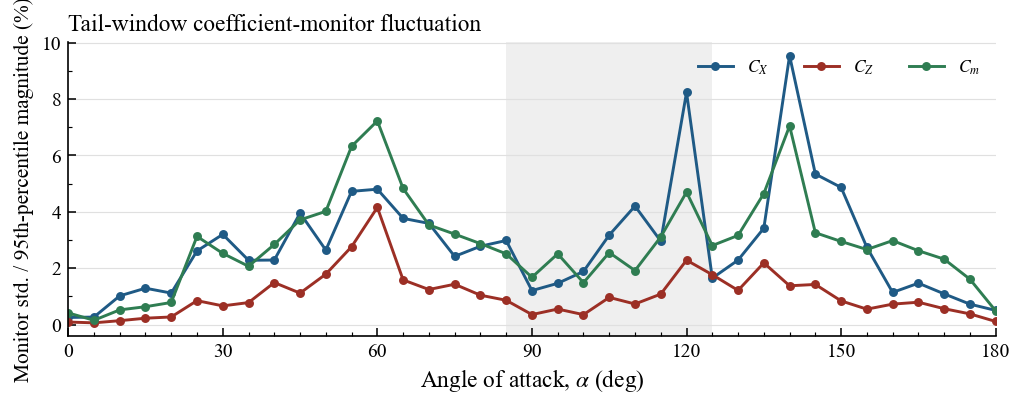

In [14]:
def plot_monitor_fluctuation_qc(data):
    """绘制尾窗标准差的归一化 QC 图。"""
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)

    for spec in PANEL_SPECS:
        coef = data[spec["col"]].to_numpy(dtype=float)
        std = data[spec["std"]].to_numpy(dtype=float)
        scale = np.nanpercentile(np.abs(coef), 95)
        ratio = 100 * std / max(scale, 1e-12)
        ax.plot(
            data["alpha_deg"],
            ratio,
            marker="o",
            ms=3.6,
            lw=1.5,
            color=spec["color"],
            label=spec["ylabel"],
        )

    ax.axvspan(REVIEW_BAND[0], REVIEW_BAND[1], color="0.86", alpha=0.42, lw=0)
    ax.set_xlim(0, 180)
    ax.set_xlabel(r"Angle of attack, $\alpha$ (deg)", fontsize=12)
    ax.set_ylabel("Monitor std. / 95th-percentile magnitude (%)", fontsize=11)
    ax.set_title("Tail-window coefficient-monitor fluctuation", fontsize=12, loc="left")
    ax.xaxis.set_major_locator(MultipleLocator(30))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(axis="y", color="0.88", lw=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", ncol=3, fontsize=9)
    return fig, ax


fig_qc, ax_qc = plot_monitor_fluctuation_qc(df)
plt.show()

## 8. Manuscript use notes

- `C_X`, `C_Z`, and `C_m` are the final model-input coefficients from `coefficients_final_lookup.csv`.
- The shaded band is the standard deviation of the coefficient monitor over the final 500 iterations; it only indicates numerical monitor fluctuation, not full CFD uncertainty.
- The 85--125 deg review band is kept in the numerical check table and optional QC plot, not in the main figure.
- The smooth line is for visual guidance; the hollow markers are the actual 5 deg CFD samples.
- Static AoA CFD maps should be described only as quasi-static load closure: `X=QAC_X`, `Z=QAC_Z`, `M=QALC_m`.